In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('house_price_linear_regression_dataset.csv')
df

,area_sqft,bedrooms,bathrooms,floors,parking,house_age,price_lakhs
0,775,4,3,3,1,15,66.30
1,1820,1,4,3,0,28,104.26
2,1137,5,2,3,1,15,96.38
3,3150,1,1,1,2,24,129.61
4,2203,2,1,2,2,29,122.25
...,...,...,...,...,...,...,...
295,2074,1,2,2,2,34,88.63
296,1508,4,3,2,0,29,92.64
297,3470,4,4,2,0,23,193.88
298,1712,1,1,1,1,23,89.47


In [4]:
# Feature Selection

In [5]:
y = df['price_lakhs']
x = df.drop(columns=["price_lakhs"])
x

,area_sqft,bedrooms,bathrooms,floors,parking,house_age
0,775,4,3,3,1,15
1,1820,1,4,3,0,28
2,1137,5,2,3,1,15
3,3150,1,1,1,2,24
4,2203,2,1,2,2,29
...,...,...,...,...,...,...
295,2074,1,2,2,2,34
296,1508,4,3,2,0,29
297,3470,4,4,2,0,23
298,1712,1,1,1,1,23


In [6]:
# Different features corelation with price

In [7]:
corr = df.corr()["price_lakhs"].sort_values(ascending=False)
corr

price_lakhs    1.000000
area_sqft      0.932016
bedrooms       0.242868
parking        0.143047
bathrooms      0.126749
floors        -0.000877
house_age     -0.088154
Name: price_lakhs, dtype: float64

In [8]:
corr = ( 
    df.corr()["price_lakhs"] 
    .drop("price_lakhs") 
    .sort_values(ascending=False)
)
corr

area_sqft    0.932016
bedrooms     0.242868
parking      0.143047
bathrooms    0.126749
floors      -0.000877
house_age   -0.088154
Name: price_lakhs, dtype: float64

In [9]:
# Feature importance
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x, y)

importance = pd.Series(
    model.coef_,
    index=x.columns
).sort_values(key=abs, ascending=False)

importance

bedrooms     6.144628
floors       4.003375
bathrooms    3.845475
parking      1.707814
house_age   -0.553733
area_sqft    0.045643
dtype: float64

In [10]:
# Explnation = Increasing 1 extra bedroom will increase the price by 6.144 lakhs

In [11]:
# Train - Test split process

In [12]:
# ================================
# STEP 6: Train–Test Split
# Dataset shape: 300 x 7
# Target variable: price_lakhs
# ================================

from sklearn.model_selection import train_test_split

# Features and target
# X = df.drop("price_lakhs", axis=1)   # 6 feature columns
# y = df["price_lakhs"]                # target column

# Train–Test split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,        # 20% test data
    random_state=42
)

# Verify sizes
print("Original dataset shape :", df.shape)
print("X_train shape          :", x_train.shape)
print("X_test shape           :", x_test.shape)
print("y_train shape          :", y_train.shape)
print("y_test shape           :", y_test.shape)


Original dataset shape : (300, 7)
X_train shape          : (240, 6)
X_test shape           : (60, 6)
y_train shape          : (240,)
y_test shape           : (60,)


In [13]:
x_train

,area_sqft,bedrooms,bathrooms,floors,parking,house_age
232,2548,5,3,3,2,29
59,3227,5,1,2,0,11
6,1519,3,4,3,1,19
185,1473,3,4,3,2,15
173,2548,1,2,2,2,16
...,...,...,...,...,...,...
188,2878,3,3,3,0,25
71,2039,2,4,2,0,9
106,2532,3,2,3,2,32
270,2170,5,4,3,2,31


In [14]:
x_test

,area_sqft,bedrooms,bathrooms,floors,parking,house_age
203,3109,1,1,1,2,17
266,2343,5,2,2,2,27
152,2979,4,2,1,0,19
9,3183,4,2,2,2,3
233,2697,2,1,3,0,10
226,2792,3,1,3,1,24
196,2856,5,4,1,2,12
109,1166,1,2,3,0,4
5,811,5,3,2,2,1
175,888,5,1,1,2,24


In [15]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(x_train, y_train)


LinearRegression()

In [16]:
y_pred = lr_model.predict(x_test)
y_pred

array([147.00072299, 139.2459893 , 159.0640635 , 184.46366672,
       142.49681726, 147.05377153, 174.801517  ,  73.8494384 ,
        87.82273628,  67.05835066, 148.43133779,  70.76437607,
       135.9133807 , 155.0157756 ,  75.81273851,  79.09431529,
        83.32713134, 137.83272434, 119.58381698, 138.39973294,
       146.13571866,  77.3007791 , 120.32215693, 117.72925993,
        62.50954691, 189.14486844, 117.52410944,  98.24245912,
       121.49670751,  74.34509376, 123.70863662,  89.43489235,
       161.50618341, 109.77549054, 170.78079487,  99.18409956,
       103.64776275,  61.74661326, 168.62139665,  80.47886498,
       153.14726313, 137.83737072, 130.81366886,  96.1044057 ,
       153.07697951,  80.7394865 ,  62.01506892,  86.74663334,
        71.32840037,  54.78825934, 129.10363248,  69.59108046,
       143.58515203, 131.79580715, 190.74680307, 159.82702967,
       167.11597184, 145.87348397,  54.97744103,  88.01041174])

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


MAE : 5.310969441557982
RMSE: 6.6424212958246365
R²  : 0.9711664775642427


In [18]:
feature_importance = pd.Series(
    lr_model.coef_,
    index=x.columns
).sort_values(key=abs, ascending=False)

feature_importance


bedrooms     6.226905
bathrooms    3.878659
floors       3.809034
parking      1.740444
house_age   -0.552134
area_sqft    0.045468
dtype: float64

<Axes: xlabel='Actual Price (Lakhs)', ylabel='Predicted Price (Lakhs)'>

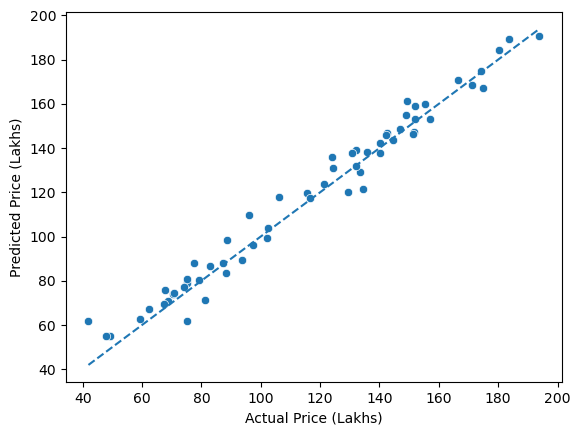

In [19]:
import seaborn as sns
import pandas as pd

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    "Actual Price (Lakhs)": y_test,
    "Predicted Price (Lakhs)": y_pred
})

# Scatter plot
sns.scatterplot(
    data=comparison_df,
    x="Actual Price (Lakhs)",
    y="Predicted Price (Lakhs)"
)

# Perfect prediction line (seaborn only)
sns.lineplot(
    x=comparison_df["Actual Price (Lakhs)"],
    y=comparison_df["Actual Price (Lakhs)"],
    linestyle="--"
)



In [20]:
lr_model

LinearRegression()

In [21]:
import pickle
with open("house_price_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

print("Model trained and saved successfully!")

Model trained and saved successfully!
